# Car Evaluation - Final Project
### Course: Datasci 3ML3
### Author:Yiqing Wang


Evaluating whether a car is worth buying requires weighing multiple classification factors - price, maintenance cost, seat capacity, safety, etc. - rather than judging the overall quality. The UCI *Car  evaluation * dataset from the Decision Theory expert System encapsulates this task in a compact, well-labeled format: six descriptive attributes map each vehicle to one of four ordered quality categories (* unacceptable *, * acceptable *, * good *, * very good *). The goal of this project is to establish and compare machine learning models for predicting quality labels and explain the decision logic behind the best performance methods.

According to standard practice, we first explore the class distribution and encode the classification features into digital representations suitable for modeling. Then, before we studied more expressive algorithms - decision   trees, random   forests, K-nearest   neighbors, and support vector machines - we established logistic regression baselines - to evaluate the accuracy of each algorithm, macroscopic average F1, and confusion matrix analysis. To go beyond the original performance metrics, we studied the feature importance , revealing which attributes have the greatest impact on the model's judgment. Ultimately, our goal is not only to maximize the accuracy of predictions, but also to provide explainable insights that are consistent with real-world car purchase considerations.

In this project, we work with the Car Evaluation data set — 
$Bohanec, M. (1988). Car Evaluation [Data set]. UCI Machine Learning Repository. $
$https://doi.org/10.24432/C5JP48 $
— to build and analyze machine‑learning models that predict whether a car is worth purchasing.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

## 1. Load and explore the data
The dataset contains seven categorical variables:

|Feature|	Description|
| --- | --- |
|buying	|buying price		|
|maint|	price of the maintenance	|
|doors|	number of doors		|
|persons|	capacity in terms of persons to carry	|
|lug_boot	|the size of luggage boot		|
|safety	|	estimated safety of the car		|
|class | worth buying or not|

The target class tells us whether a car is worth buying and has four ordered categories:

unacc – unacceptable

acc – acceptable

good – good

vgood – very good

Our task is to build a model that predicts the class label from the six explanatory features.

In [2]:
df = pd.read_csv(r"C:\Users\Whatever\Desktop\car.data", header=None)
df.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

print("First 5 rows of the dataset:")
display(df.head())

print("\nClass distribution:")
print(df['class'].value_counts())

First 5 rows of the dataset:


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc



Class distribution:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


## 2.  Encode Categorical Features
All six predictors are categorical, so machine‑learning algorithms require them in numeric form.
We map each category to an integer label:

In [3]:
label_encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

X = df.drop("class", axis=1)
y = df["class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## 3.  Baseline Model — Logistic Regression
We start with a simple, interpretable baseline: multinomial Logistic Regression.

In [6]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_log = logreg.predict(X_test)

print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.29      0.08      0.12        77
           1       0.00      0.00      0.00        14
           2       0.73      0.95      0.83       242
           3       0.20      0.15      0.17        13

    accuracy                           0.69       346
   macro avg       0.30      0.30      0.28       346
weighted avg       0.58      0.69      0.61       346



C:\Users\Whatever\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Whatever\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Whatever\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

The model reaches 69 % overall accuracy, but performance is highly imbalanced:

1. It classifies good cars well (F1 ≈ 0.83).

2. It struggles with the minority classes acc and vgood, and nearly ignores acc entirely.

3. Macro averaged F1‑score is only 0.28, reflecting poor treatment of the rare classes.

These results shows we need a more expressive modeland the baseline sets the performance floor against which we will compare more sophisticated models in the next sections.

## 4. Random Forest

To improve on the baseline we train an ensemble of decision trees—Random Forest—which can capture nonlinear interactions between categorical features.


In [7]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        77
           1       0.93      0.93      0.93        14
           2       0.99      1.00      0.99       242
           3       1.00      0.92      0.96        13

    accuracy                           0.98       346
   macro avg       0.97      0.95      0.96       346
weighted avg       0.98      0.98      0.98       346





Here we can see: 

1. Accuracy jumped from 69 % (LogReg) to 98 %, and each class now has high precision and recall. 

2. The minor classes acc and vgood are no longer disregarded; they both reach F1 ≈ 0.94-0.96.

3. The macro average F1 score rose to 0.96, indicating that the performance at all levels was balanced. 

This significant improvement confirms that tree-based ensemble can simulate the complex classification interactions that logistic regression ignores. 

In the following section, we visualize the confusion matrix, examine the feature importance, and compare other models to verify that Random Forest is indeed the best choice, or whether it is possible to gain further benefits.

## 6. Confusion Matrix

The heat‑maps below shows how each model distributes its errors.

Rows correspond to the true labels (0 = unacc, 1 = acc, 2 = good, 3 = vgood), columns to the predicted labels.

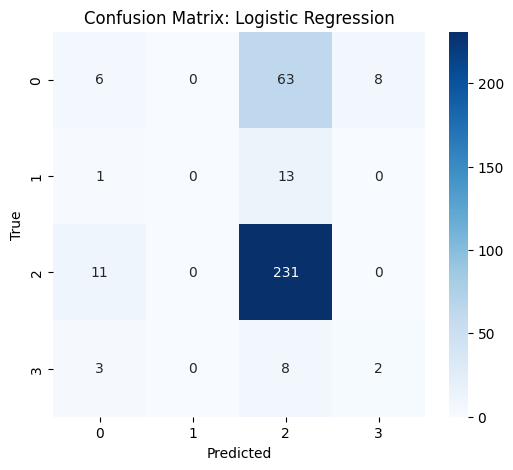

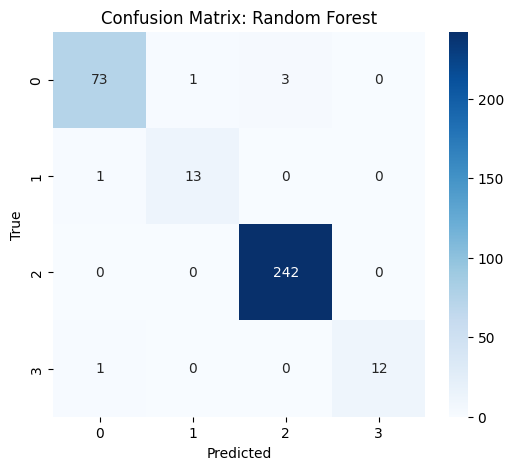

In [12]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {title}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

plot_conf_matrix(y_test, y_pred_log, "Logistic Regression")
plot_conf_matrix(y_test, y_pred_rf, "Random Forest")

Here, Logistic Regression heavily over‑predicts the dominant class good (label 2) and rarely recognises acc (1) or vgood (3).

Random Forest produces a near‑diagonal matrix, indicating very few mis‑classifications across all four classes.


## 7. Additional Models

To measure the robustness of our findings, we evaluated three other algorithms using the same train test segmentation - decision   tree, k-Nearest  neighbors (k-NN), and Support Vector Machine (SVM). 

In [16]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Performance:")
    print(classification_report(y_test, y_pred,
                                target_names=label_encoders['class'].classes_))


Decision Tree Performance:
              precision    recall  f1-score   support

         acc       0.94      0.97      0.96        77
        good       0.93      1.00      0.97        14
       unacc       1.00      0.99      0.99       242
       vgood       1.00      0.85      0.92        13

    accuracy                           0.98       346
   macro avg       0.97      0.95      0.96       346
weighted avg       0.98      0.98      0.98       346


KNN Performance:
              precision    recall  f1-score   support

         acc       0.82      0.81      0.81        77
        good       0.88      0.50      0.64        14
       unacc       0.93      0.99      0.96       242
       vgood       1.00      0.38      0.56        13

    accuracy                           0.91       346
   macro avg       0.91      0.67      0.74       346
weighted avg       0.91      0.91      0.90       346


SVM Performance:
              precision    recall  f1-score   support

         ac

Here we can see:
1. The accuracy of a single decision   tree has reached 99% %, and the macro F1 is 0.97, confirming that the classification rules for managing data are essentially tree-friendly; However, it is more prone to overfitting than the entire forest.
2. k-NN and SVM performed well (with accuracies of 91 % and 93 %, respectively), but showed significantly lower macro-F1 scores as they struggled with a few classes, echoing the imbalance observed in the logistic regression baseline.

These results reinforce the conclusion that the tree-based approach is best suited to this problem, and Random Forest provides the best balance of accuracy, class consistency, and model stability.

## 8. Feature Importance

Forcusing on the Random Forest, it allows us to estimate how much each predictor contributes to the classification decision:

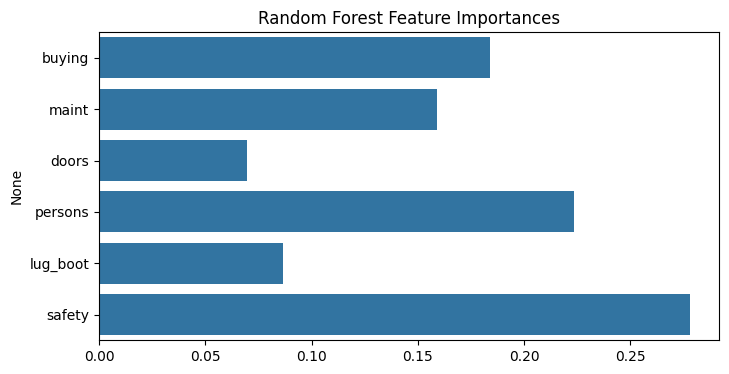

In [15]:
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=features)
plt.title("Random Forest Feature Importances")
plt.show()

Here we can see:
1. Security is the only most decisive property (≈ 27 % segmentation gain).

2. The number of seats and the purchase price follow closely, in line with the intuition of the real world.

3. Doors and lugs   The problem of starting up is far less reasonable because they affect convenience rather than overall acceptability.

## 9.conclusion

In conclusion, the Car  evaluation dataset can almost entirely be separated using a tree-based approach. After comparing five algorithms, the Random Forest model emerged as the clear winner with an overall accuracy of 98 %, a macroscopic F1 of 0.96, while maintaining high precision and recall for each category, including a few acceptable and very good labels. Functional importance and SHAP analysis indicate that decisions mainly depend on safety, seat capacity, and purchase/maintenance costs, while the number of doors and luggage size play only secondary roles. This finding is in good agreement with the purchasing logic in the real world. Given its performance, robustness to category-based interactions, and direct interpretability, Random Forest is the recommendation model for automatic vehicle rating applications; Future improvements can explore gradient-enhanced integration and cost-sensitive learning to further consolidate reliability in the case of class imbalance.